In [1]:
import os 
cwd = os.getcwd()
cwd

os.chdir("/Users/jmthomas565/Desktop/Education/Applied Stats MSc/MSc Project/Git Files/msc-project-source-code-files-24-25-jmthomas565/Code/Project Code Pipeline")

new_cwd = os.getcwd() 

new_cwd


'/Users/jmthomas565/Desktop/Education/Applied Stats MSc/MSc Project/Git Files/msc-project-source-code-files-24-25-jmthomas565/Code/Project Code Pipeline'

In [2]:
%run 00_inititial_transformations.ipynb

['2017-07-01', '2017-07-02', '2017-07-03', '2017-07-04', '2017-07-05'] ... ['2022-09-27', '2022-09-28', '2022-09-29', '2022-09-30', '2022-10-01']


In [3]:
X_train_select = X_train.iloc[:,:4]

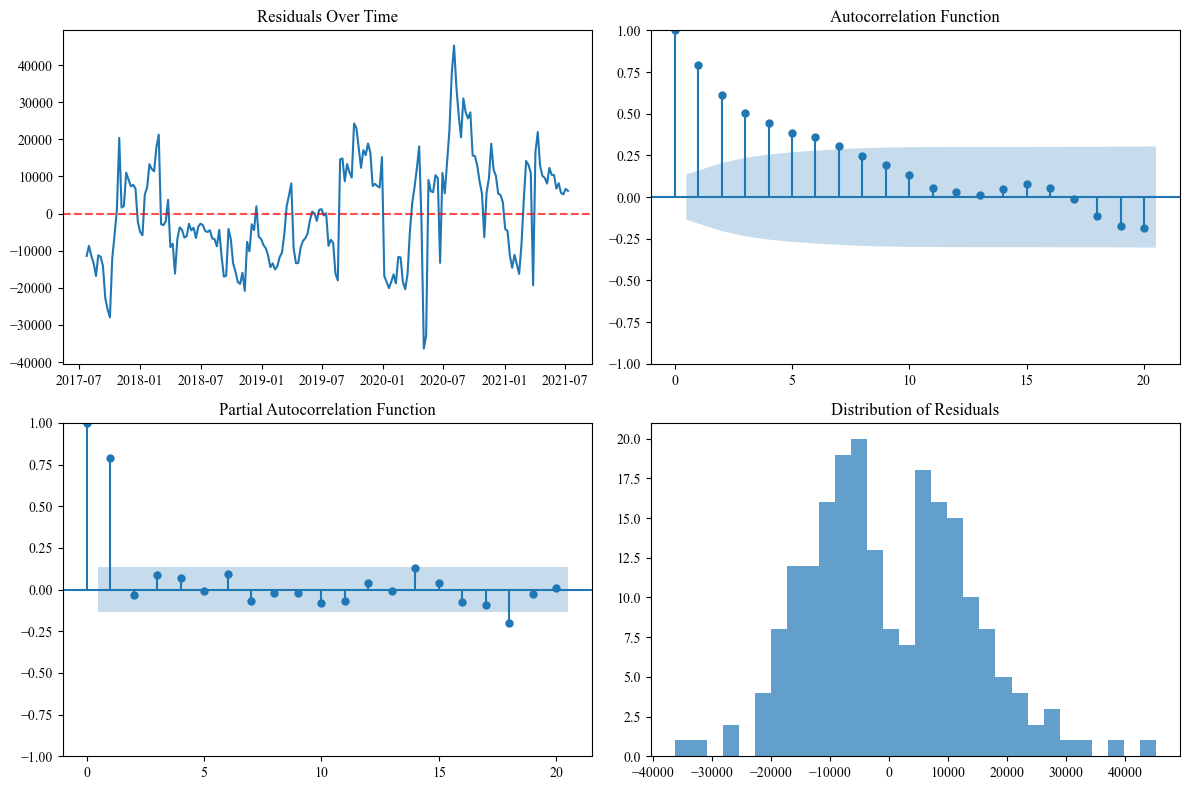

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import sklearn.linear_model as lm


model = lm.Ridge()
model.fit(X_train_select, y_train)

#calculating the resids
y_pred = model.predict(X_train_select)
resids = y_train - y_pred

#plotting the resids
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

plt.rcParams['font.family'] = 'Times New Roman'

axes[0,0].plot(resids)
axes[0,0].set_title('Residuals Over Time')
axes[0,0].axhline(y=0, color='r', linestyle='--', alpha=0.7)

#ACF plot
plot_acf(resids, ax=axes[0,1],lags=20, title='Autocorrelation Function')

#PACF plot 
plot_pacf(resids, ax=axes[1,0], lags=20, title='Partial Autocorrelation Function')

#resids plot
axes[1,1].hist(resids, bins=30, alpha=0.7)
axes[1,1].set_title('Distribution of Residuals')

plt.tight_layout()
plt.show()
